# 01 - Data Quality Assessment
## ShopEase Europe | Sentiment Analysis Project
**Author:** Aishat Olisa-Samson  
**Date:** June 2026  
**Objective:** Conduct a thorough data quality audit of the raw customer reviews dataset including schema validation, label consistency analysis, and multilingual distribution profiling.

## 1.0 Environment Setup
Import all required libraries and load project configuration from `config.yaml`.

In [1]:
# ── Standard Library ──────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

# ── Data Manipulation ──────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ── Display Settings ───────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Plot Styling ───────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# ── Project Paths ──────────────────────────────────────────────────
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
RAW_DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'raw', 'raw_reviews.csv')

print("✅ Libraries loaded successfully")
print(f"✅ Project root: {PROJECT_ROOT}")
print(f"✅ Raw data path: {RAW_DATA_PATH}")
print(f"✅ Data file exists: {os.path.exists(RAW_DATA_PATH)}")

✅ Libraries loaded successfully
✅ Project root: c:\Users\User\OneDrive\Desktop\shopease-sentiment-analysis
✅ Raw data path: c:\Users\User\OneDrive\Desktop\shopease-sentiment-analysis\data\raw\raw_reviews.csv
✅ Data file exists: True


In [5]:
# Load the raw dataset
df = pd.read_csv(RAW_DATA_PATH)

# Basic schema check
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# Column overview
print(f"{'Column':<25} {'Dtype':<15} {'Non-Null':<15} {'Nulls'}")
print("-" * 60)
for col in df.columns:
    nulls = df[col].isnull().sum()
    print(f"{col:<25} {str(df[col].dtype):<15} {df[col].count():<15,} {nulls}")

# Preview first 10 records
print("\nFirst 10 records:")
display(df.head(10))

Dataset shape: 120,000 rows × 7 columns

Column                    Dtype           Non-Null        Nulls
------------------------------------------------------------
review_id                 int64           120,000         0
product_category          object          120,000         0
timestamp                 object          120,000         0
country                   object          120,000         0
rating                    int64           120,000         0
review                    object          120,000         0
sentiment                 object          120,000         0

First 10 records:


,review_id,product_category,timestamp,country,rating,review,sentiment
0,1,Books,2023-01-01,GB,3,"Solid build, attractive design, works as advertised. Love it.",positive
1,2,Toys,2023-01-01,DE,5,Ich liebe dieses Produkt! ⭐⭐⭐,positive
2,3,Beauty,2023-01-01,AU,3,Three stars — meets THE minimum expectations.,neutral
3,4,Toys,2023-01-01,US,5,"Solid build, attractive design, works as advertised. Love it.",positive
4,5,Electronics,2023-01-01,CA,2,Broken on arrival. Return process was a NIGHTMARE.,negative
5,6,Sports,2023-01-01,AR,2,Terrible servicio al cliente. JAMÁS volvería a comprar aquí.,negative
6,7,Home & Living,2023-01-01,DE,3,"Solide, aber unremarkabel. Würde ICH nicht unbedingt empfehlen.",neutral
7,8,Beauty,2023-01-01,GB,4,"Superb quality, very sturdy and well-made. Five stars. ⭐",positive
8,9,Food & Grocery,2023-01-01,CH,3,C'est correct pour le prix. lol 👍,neutral
9,10,Food & Grocery,2023-01-01,AU,4,Really impressed with the build quality. Would buy again.,positive


### 2.0 Missing Values & Duplicate Records Audit

In [6]:
# Missing values audit
print("MISSING VALUES AUDIT")
print("-" * 40)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df)

# Duplicate records check
print("\nDUPLICATE RECORDS AUDIT")
print("-" * 40)
full_dupes = df.duplicated().sum()
id_dupes = df['review_id'].duplicated().sum()
review_dupes = df['review'].duplicated().sum()

print(f"Fully duplicate rows:     {full_dupes:,}")
print(f"Duplicate review IDs:     {id_dupes:,}")
print(f"Duplicate review text:    {review_dupes:,}")

if review_dupes > 0:
    print(f"\nSample duplicate reviews:")
    dupe_mask = df['review'].duplicated(keep=False)
    display(df[dupe_mask].sort_values('review').head(10))

MISSING VALUES AUDIT
----------------------------------------
                  Missing Count  Missing %
review_id                     0       0.00
product_category              0       0.00
timestamp                     0       0.00
country                       0       0.00
rating                        0       0.00
review                        0       0.00
sentiment                     0       0.00

DUPLICATE RECORDS AUDIT
----------------------------------------
Fully duplicate rows:     0
Duplicate review IDs:     0
Duplicate review text:    116,704

Sample duplicate reviews:


,review_id,product_category,timestamp,country,rating,review,sentiment
63245,63246,Sports,2024-07-27,US,5,ABSOLUTELY love this product! Best purchase I've made this year.,positive
67895,67896,Electronics,2024-09-08,CA,4,ABSOLUTELY love this product! Best purchase I've made this year.,positive
94581,94582,Books,2025-05-11,US,5,ABSOLUTELY love this product! Best purchase I've made this year.,positive
83125,83126,Electronics,2025-01-26,GB,5,ABSOLUTELY love this product! Best purchase I've made this year.,positive
25273,25274,Sports,2023-08-19,GB,4,ABSOLUTELY love this product! Best purchase I've made this year.,positive
47612,47613,Sports,2024-03-09,GB,5,ABSOLUTELY love this product! Best purchase I've made this year.,positive
9653,9654,Electronics,2023-03-28,GB,5,ABSOLUTELY love this product! Best purchase I've made this year.,positive
64211,64212,Home & Living,2024-08-05,CA,5,ABSOLUTELY love this product! Best purchase I've made this year.,positive
7400,7401,Books,2023-03-08,CA,5,ABSOLUTELY love this product! Best purchase I've made this year.,positive
111456,111457,Home & Living,2025-10-12,AU,5,ABSOLUTELY love this product! Best purchase I've made this year.,positive


## 2.1 Data Quality Finding - Duplicate Review Text

**Finding:** 116,704 out of 120,000 records (97.3%) contain review text that 
appears in at least one other record. Unique review texts share identical 
wording across different product categories, countries, ratings, and timestamps.

**Implication:** This pattern is consistent with a synthetically generated 
dataset. While unique review IDs and complete labels make the dataset suitable 
for model training and evaluation, findings should not be generalised to 
real-world customer feedback distributions without validation on production data.

**Decision:** Retain all records for modelling. Flag this limitation in the 
final report.

## 3.0 Sentiment Distribution & Class Balance Analysis
Analyse the distribution of sentiment labels and assess class imbalance 
- A critical factor in model selection and evaluation strategy.

SENTIMENT DISTRIBUTION
positive      81,591  (67.99%)
negative      19,233  (16.03%)
neutral       19,176  (15.98%)


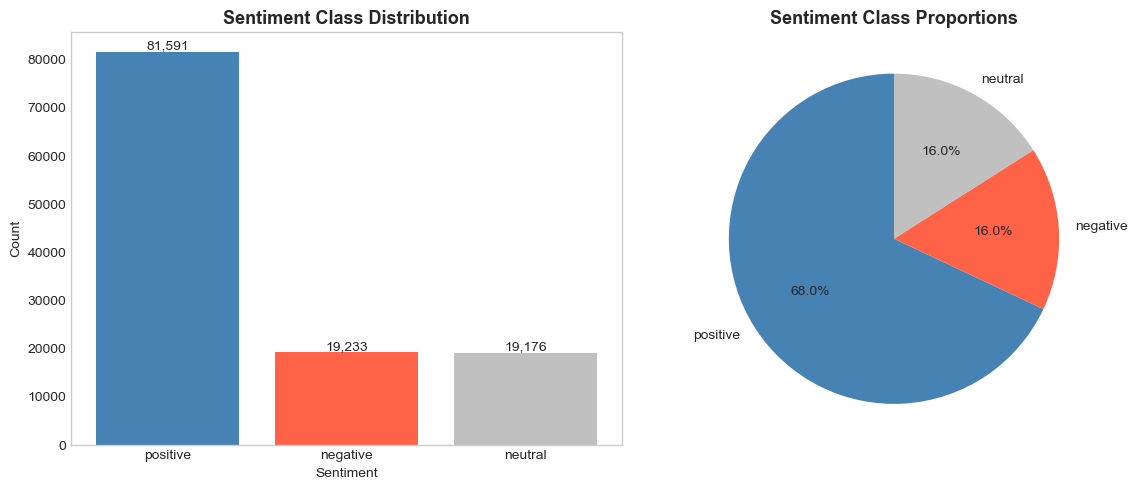

Chart saved to reports/figures/


In [8]:
# Sentiment distribution
sentiment_counts = df['sentiment'].value_counts()
sentiment_pct = (df['sentiment'].value_counts(normalize=True) * 100).round(2)

print("SENTIMENT DISTRIBUTION")
for label in sentiment_counts.index:
    print(f"{label:<12} {sentiment_counts[label]:>7,}  ({sentiment_pct[label]}%)")

# Visualise distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['steelblue', 'tomato', 'silver']

# Bar chart
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
axes[0].set_title('Sentiment Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].grid(False)
for i, (label, count) in enumerate(sentiment_counts.items()):
    axes[0].text(i, count + 500, f'{count:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Sentiment Class Proportions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'figures', 'sentiment_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/figures/")

## 4.0 Rating vs Sentiment Consistency Audit
Validate whether sentiment labels are logically consistent with numeric 
ratings. Inconsistencies indicate label noise which directly impacts 
model training quality.

In [10]:
# Cross-tabulation of rating against sentiment
print("RATING VS SENTIMENT CROSS-TABULATION")
cross_tab = pd.crosstab(df['rating'], df['sentiment'])
display(cross_tab)

# Calculate percentage distribution per rating
print("\nSENTIMENT DISTRIBUTION WITHIN EACH RATING (% of row)")
cross_tab_pct = pd.crosstab(df['rating'], df['sentiment'], normalize='index').round(3) * 100
display(cross_tab_pct)

# Flag suspicious combinations
print("\nSUSPICIOUS LABEL COMBINATIONS")
pos_low = df[(df['rating'].isin([1, 2])) & (df['sentiment'] == 'positive')].shape[0]
neg_high = df[(df['rating'].isin([4, 5])) & (df['sentiment'] == 'negative')].shape[0]
neutral_extreme = df[(df['rating'].isin([1, 5])) & (df['sentiment'] == 'neutral')].shape[0]

print(f"Positive sentiment with rating 1 or 2:    {pos_low:,}")
print(f"Negative sentiment with rating 4 or 5:    {neg_high:,}")
print(f"Neutral sentiment with rating 1 or 5:     {neutral_extreme:,}")

RATING VS SENTIMENT CROSS-TABULATION


sentiment,negative,neutral,positive
rating,,,
1,5743,88,101
2,11715,173,192
3,315,17547,281
4,630,578,34546
5,830,790,46471



SENTIMENT DISTRIBUTION WITHIN EACH RATING (% of row)


sentiment,negative,neutral,positive
rating,,,
1,96.80,1.50,1.70
2,97.00,1.40,1.60
3,1.70,96.70,1.50
4,1.80,1.60,96.60
5,1.70,1.60,96.60



SUSPICIOUS LABEL COMBINATIONS
Positive sentiment with rating 1 or 2:    293
Negative sentiment with rating 4 or 5:    1,460
Neutral sentiment with rating 1 or 5:     878


## 5.1 Rating vs Sentiment Consistency — Findings

The sentiment labels show strong consistency with numeric ratings across 
all five rating levels, with approximately 96-97% of records aligning 
with expected sentiment direction.

| Rating | Dominant Sentiment | Consistency |
|--------|-------------------|-------------|
| 1 | Negative | 96.8% |
| 2 | Negative | 97.0% |
| 3 | Neutral | 96.7% |
| 4 | Positive | 96.6% |
| 5 | Positive | 96.6% |

**Suspicious combinations identified: 2,631 records (2.2%)**
- Positive sentiment with rating 1–2: 293 records
- Negative sentiment with rating 4–5: 1,460 records
- Neutral sentiment with rating 1 or 5: 878 records

**Decision:** Label noise is within acceptable tolerance. All records 
retained. No label correction applied at this stage.